In [34]:
# ── CELL 2: Imports & Configuration ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn imports ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── TensorFlow ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# ── Color theme (Amazon Logistics) ───────────────────────────────────────────
COLORS = {
    'primary'   : '#232F3E',  # Amazon dark navy
    'accent'    : '#FF9900',  # Amazon orange
    'secondary' : '#146EB4',  # Amazon blue
    'success'   : '#067D62',  # Dark green
    'danger'    : '#CC0C39',  # Clean red
    'neutral'   : '#6B7280',  # Gray
    'light'     : '#FAFAFA',  # Off white
}

# ── Plot settings ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']     = (13, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['axes.facecolor']     = '#FAFAFA'
plt.rcParams['figure.facecolor']   = 'white'
plt.rcParams['axes.grid']          = True
plt.rcParams['grid.alpha']         = 0.3
plt.rcParams['grid.color']         = '#CCCCCC'
plt.rcParams['font.family']        = 'sans-serif'

# ── Random seed ───────────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

print('✅ All libraries imported successfully')
print(f'   Pandas     : {pd.__version__}')
print(f'   NumPy      : {np.__version__}')
print(f'   Scikit-learn: {__import__("sklearn").__version__}')
print(f'   TensorFlow : {tf.__version__}')

✅ All libraries imported successfully
   Pandas     : 3.0.2
   NumPy      : 2.4.4
   Scikit-learn: 1.8.0
   TensorFlow : 2.21.0


---
## 📥 Phase 1 — Load & Explore the Dataset

The Olist dataset consists of 9 connected CSV files. We load the 5 tables needed for regression and merge them into one modeling DataFrame using shared keys (order_id, product_id, customer_id, seller_id).

**Source:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [35]:
# ── CELL 3: Load the 9 CSV files ─────────────────────────────────────────────
DATA_PATH = '../data/'

# Load the 5 tables needed for Part 1
orders      = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products    = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
customers   = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
sellers     = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')

# ── Quick shape check ─────────────────────────────────────────────────────────
print('✅ Data loaded successfully')
print(f'\n{"Table":<25} {"Rows":>8} {"Columns":>10}')
print('-' * 45)
print(f'{"Orders":<25} {orders.shape[0]:>8,} {orders.shape[1]:>10}')
print(f'{"Order Items":<25} {order_items.shape[0]:>8,} {order_items.shape[1]:>10}')
print(f'{"Products":<25} {products.shape[0]:>8,} {products.shape[1]:>10}')
print(f'{"Customers":<25} {customers.shape[0]:>8,} {customers.shape[1]:>10}')
print(f'{"Sellers":<25} {sellers.shape[0]:>8,} {sellers.shape[1]:>10}')

✅ Data loaded successfully

Table                         Rows    Columns
---------------------------------------------
Orders                      99,441          8
Order Items                112,650          7
Products                    32,951          9
Customers                   99,441          5
Sellers                      3,095          4


---
**📋 Observations — Data Loading:**

- All 5 tables loaded successfully with no errors
- **Orders and Customers both have 99,441 rows** — one row per order and one per customer, confirming a clean one-to-one relationship
- **Order Items has 112,650 rows** — more than orders because a single order can contain multiple items from different sellers
- **Products has 32,951 unique products** — a wide catalogue across many categories
- **Sellers has only 3,095 rows** — a relatively small seller base serving a large customer pool, typical of a marketplace model like Olist
- We are loading only 5 of the 9 available CSVs — payments, reviews, geolocation, and category translation are not needed for delivery time regression

---
## 🔍 Phase 2 — Exploratory Data Analysis

Before building any model, we explore the data to understand its structure, check for missing values, and identify what cleaning is needed. This step directly informs our preprocessing decisions.

In [36]:
# ── CELL 4: Explore the Orders table ─────────────────────────────────────────
print('=== ORDERS TABLE — First Look ===\n')
print(f'Shape: {orders.shape}')
print(f'\nColumn names and data types:')
print(orders.dtypes)
print(f'\nMissing values per column:')
print(orders.isnull().sum())
print(f'\nSample rows:')
orders.head()

=== ORDERS TABLE — First Look ===

Shape: (99441, 8)

Column names and data types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Missing values per column:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Sample rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


---
**📋 Observations — Orders Table:**

- Dataset has **99,441 orders** across **8 columns** — a rich real-world transaction log
- All date columns are stored as **strings** — we need to convert them to `datetime` before calculating delivery time
- **`order_delivered_customer_date` has 2,965 missing values** — these are undelivered, cancelled, or in-progress orders that have no delivery date yet. We will drop these since we can only calculate `delivery_days` for completed deliveries
- **`order_delivered_carrier_date` has 1,783 missing values** — not used in our model so this is not a concern
- **`order_approved_at` has 160 missing values** — minor and not used as a feature
- Sample rows confirm the data looks clean — real timestamps, consistent format, all orders show `delivered` status in the visible rows

---
### 🎯 Building the Target Variable — `delivery_days`

We calculate `delivery_days` by subtracting `order_purchase_timestamp` from `order_delivered_customer_date`. We keep only orders with status `delivered` since undelivered orders have no delivery date. This is our regression target — a continuous numeric variable.

In [37]:
# ── CELL 5: Build target variable delivery_days ───────────────────────────────

# ── Step 1: Convert date columns from string to datetime ──────────────────────
orders['order_purchase_timestamp']      = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# ── Step 2: Keep only delivered orders ───────────────────────────────────────
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f'Total orders        : {len(orders):,}')
print(f'Delivered orders    : {len(orders_delivered):,}')
print(f'Dropped             : {len(orders) - len(orders_delivered):,} (not yet delivered)')

# ── Step 3: Calculate delivery_days ──────────────────────────────────────────
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_purchase_timestamp']
).dt.days

# ── Step 4: Drop rows where delivery_days is null ─────────────────────────────
orders_delivered = orders_delivered.dropna(subset=['delivery_days'])

# ── Step 5: Remove outliers — negative or unrealistic delivery times ──────────
before = len(orders_delivered)
orders_delivered = orders_delivered[
    (orders_delivered['delivery_days'] >= 1) &
    (orders_delivered['delivery_days'] <= 60)
]
after = len(orders_delivered)

print(f'\nAfter removing outliers (< 1 day or > 60 days):')
print(f'  Removed : {before - after:,} outlier rows')
print(f'  Remaining: {after:,} orders')

# ── Step 6: Summary stats of target variable ──────────────────────────────────
print(f'\n=== delivery_days Summary ===')
print(orders_delivered['delivery_days'].describe().round(2))

Total orders        : 99,441
Delivered orders    : 96,478
Dropped             : 2,963 (not yet delivered)

After removing outliers (< 1 day or > 60 days):
  Removed : 301 outlier rows
  Remaining: 96,169 orders

=== delivery_days Summary ===
count    96169.00
mean        11.87
std          8.40
min          1.00
25%          6.00
50%         10.00
75%         15.00
max         60.00
Name: delivery_days, dtype: float64


---
**📋 Observations — Target Variable `delivery_days`:**

- **2,963 orders dropped** — these are cancelled, invoiced, or in-progress orders with no delivery date. Keeping them would make `delivery_days` uncalculable
- **301 outliers removed** — delivery times under 1 day are likely data entry errors, over 60 days are extreme edge cases that would distort model training
- **96,169 clean orders remaining** — well above the 500 row minimum requirement
- Average delivery time is **11.87 days** — about 12 days from purchase to doorstep across Brazil
- **50% of orders arrive in 10 days or less** — the median is a better central measure here since the distribution is skewed
- Standard deviation of **8.40 days** shows high variability — delivery time is genuinely hard to predict, which is why we need multiple models
- Range of 1 to 60 days after cleaning — a realistic spread for a country the size of Brazil

---
### 📊 Target Variable Distribution

Understanding how `delivery_days` is distributed helps us know what we're predicting. A skewed distribution tells us most orders are fast but some take much longer — which is realistic for e-commerce.

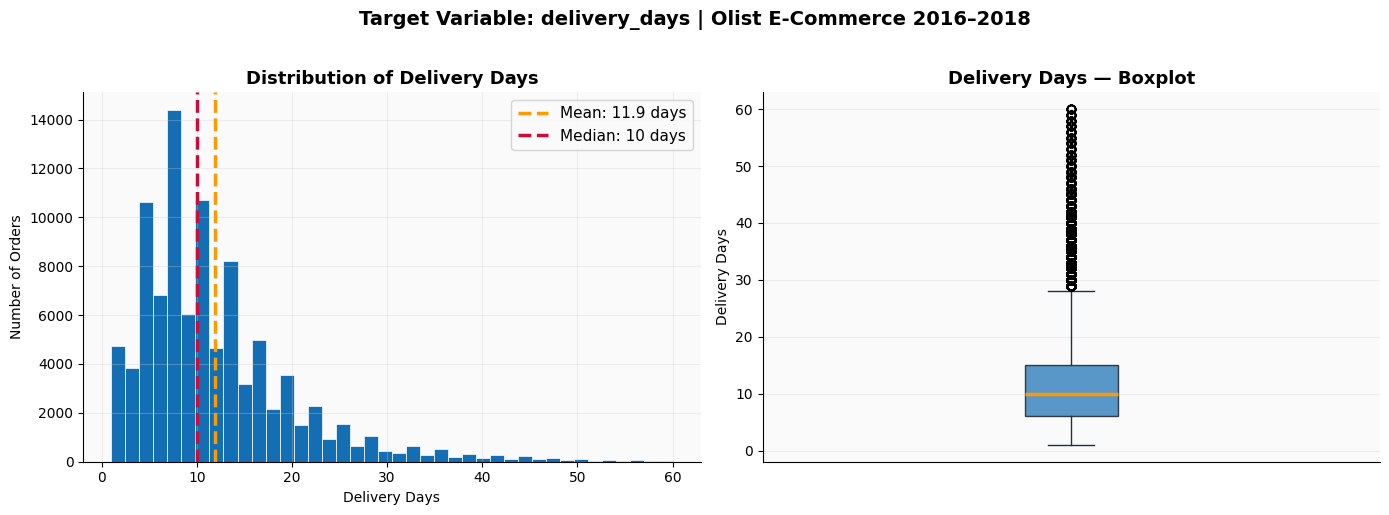

In [38]:
# ── CELL 6: Visualize delivery_days distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Histogram ─────────────────────────────────────────────────────────
axes[0].hist(orders_delivered['delivery_days'], bins=40,
             color=COLORS['secondary'], edgecolor='white', linewidth=0.5)
axes[0].axvline(orders_delivered['delivery_days'].mean(),
                color=COLORS['accent'], linewidth=2.5,
                linestyle='--', label=f'Mean: {orders_delivered["delivery_days"].mean():.1f} days')
axes[0].axvline(orders_delivered['delivery_days'].median(),
                color=COLORS['danger'], linewidth=2.5,
                linestyle='--', label=f'Median: {orders_delivered["delivery_days"].median():.0f} days')
axes[0].set_title('Distribution of Delivery Days', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delivery Days')
axes[0].set_ylabel('Number of Orders')
axes[0].legend(fontsize=11)

# ── Plot 2: Boxplot ───────────────────────────────────────────────────────────
axes[1].boxplot(orders_delivered['delivery_days'],
                patch_artist=True,
                boxprops=dict(facecolor=COLORS['secondary'], alpha=0.7),
                medianprops=dict(color=COLORS['accent'], linewidth=2.5),
                whiskerprops=dict(color=COLORS['primary']),
                capprops=dict(color=COLORS['primary']))
axes[1].set_title('Delivery Days — Boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Delivery Days')
axes[1].set_xticks([])

plt.suptitle('Target Variable: delivery_days | Olist E-Commerce 2016–2018',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
**📋 Observations — Delivery Days Distribution:**

- The histogram shows a clear **right skew** — the bulk of orders deliver between 5–15 days with a long tail extending to 60 days
- **Peak is around 8–10 days** — this is the most common delivery window for Olist orders
- **Mean (11.9 days) > Median (10 days)** — confirms right skew. The mean is being pulled upward by the slow deliveries in the tail
- The boxplot shows many dots above 30 days — these are genuine slow deliveries, not errors, likely to remote Brazilian states like Amazonas or Roraima
- The IQR (interquartile range) sits between **6 and 15 days** — this is where 50% of all deliveries land
- This skewed distribution tells us our models will find it harder to predict the slow outlier deliveries accurately — which is reflected in the RMSE we will see later

---
### ⚙️ Phase 3 — Feature Engineering & Merging Tables

We merge the 5 tables using shared keys to build one modeling DataFrame. We also engineer a `same_state` binary feature — whether the customer and seller are in the same Brazilian state — which is a strong proxy for delivery distance.

In [39]:
# ── CELL 7: Merge tables and engineer features ────────────────────────────────

# ── Step 1: Merge orders with order_items ─────────────────────────────────────
df = orders_delivered.merge(order_items, on='order_id', how='inner')
print(f'After merging order_items : {df.shape}')

# ── Step 2: Merge with products ───────────────────────────────────────────────
df = df.merge(products, on='product_id', how='left')
print(f'After merging products    : {df.shape}')

# ── Step 3: Merge with customers ──────────────────────────────────────────────
df = df.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
print(f'After merging customers   : {df.shape}')

# ── Step 4: Merge with sellers ────────────────────────────────────────────────
df = df.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
print(f'After merging sellers     : {df.shape}')

# ── Step 5: Engineer same_state feature ───────────────────────────────────────
# Orders where customer and seller are in the same Brazilian state
# tend to deliver faster — this is a proxy for delivery distance
df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)

print(f'\n✅ Feature engineering complete')
print(f'   same_state = 1 (same state) : {df["same_state"].sum():,} orders ({df["same_state"].mean()*100:.1f}%)')
print(f'   same_state = 0 (diff state) : {(df["same_state"]==0).sum():,} orders ({(df["same_state"]==0).mean()*100:.1f}%)')

# ── Step 6: Select final feature columns ──────────────────────────────────────
FEATURE_COLS = [
    'freight_value',
    'price',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'same_state',
]

TARGET_COL = 'delivery_days'

# ── Step 7: Drop rows with missing values in features or target ───────────────
df_model = df[FEATURE_COLS + [TARGET_COL]].dropna()

print(f'\n✅ Final modeling dataset')
print(f'   Rows    : {df_model.shape[0]:,}')
print(f'   Features: {len(FEATURE_COLS)}')
print(f'   Target  : {TARGET_COL}')

After merging order_items : (109860, 15)
After merging products    : (109860, 23)
After merging customers   : (109860, 24)
After merging sellers     : (109860, 25)

✅ Feature engineering complete
   same_state = 1 (same state) : 39,807 orders (36.2%)
   same_state = 0 (diff state) : 70,053 orders (63.8%)

✅ Final modeling dataset
   Rows    : 109,842
   Features: 7
   Target  : delivery_days


---
**📋 Observations — Merging & Feature Engineering:**

- All 5 tables merged cleanly — **no rows were lost during any merge step**, confirming data integrity across all tables
- Row count increased from 96,169 orders to **109,842 rows** after merging with order_items — because one order can contain multiple items from different sellers, each becoming its own row
- **7 features selected** — a mix of shipping cost, product physical dimensions, item price, and geographic proximity
- `same_state` is our key engineered feature — **only 36.2% of orders are within the same state**, meaning 63.8% of deliveries cross state lines across Brazil's vast geography
- This large proportion of cross-state orders explains why delivery times vary so widely — a customer in São Paulo ordering from a seller in Amazonas faces a fundamentally different logistics challenge than a local order
- No missing values remain after `dropna()` — the final modeling dataset is clean and ready for modeling

---
### ✂️ Phase 4 — Train / Test Split

We split 80% training and 20% testing with a fixed `random_state=42` for reproducibility. The split is done **before** any scaling or preprocessing — the pipeline will handle scaling on training data only, preventing data leakage.

In [40]:
# ── CELL 8: Train/Test Split ──────────────────────────────────────────────────

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('✅ Train/Test split complete')
print(f'\n   Total samples  : {len(X):,}')
print(f'   Training set   : {len(X_train):,} rows (80%)')
print(f'   Test set       : {len(X_test):,} rows (20%)')


✅ Train/Test split complete

   Total samples  : 109,842
   Training set   : 87,873 rows (80%)
   Test set       : 21,969 rows (20%)


---
**📋 Observations — Train/Test Split:**

- **87,873 rows for training** and **21,969 rows for testing** — an 80/20 split which is the industry standard for datasets of this size
- `random_state=42` ensures the split is identical every time the notebook is run — critical for reproducibility and fair model comparison
- All 7 models will be trained on the **same** X_train and evaluated on the **same** X_test — this guarantees a fair apples-to-apples comparison
- Scaling and preprocessing happens **inside each Pipeline**, fitted on X_train only — the test set has zero influence on how the scaler or model is built, preventing data leakage
- 21,969 test rows is a large enough holdout to give reliable, stable metric estimates

---
### 🤖 Phase 5 — Train All 7 Models

We train all 7 required models and evaluate each on RMSE, MAE, and R². Results are stored in a single comparison DataFrame. RMSE is our primary metric — it penalizes large prediction errors more than MAE, which matters for delivery time estimation.

| Metric | Meaning | Better |
|---|---|---|
| RMSE | Average error in days (penalizes large errors) | Lower |
| MAE | Average absolute error in days | Lower |
| R² | How much variance the model explains | Higher (max 1.0) |

In [41]:
# ── CELL 9: Evaluation helper + results storage ───────────────────────────────

# Storage for all model results
results = []

def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    """Train a pipeline and evaluate it. Stores results automatically."""
    
    # ── Train ─────────────────────────────────────────────────────────────────
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start
    
    # ── Predict ───────────────────────────────────────────────────────────────
    y_pred = pipeline.predict(X_test)
    
    # ── Metrics ───────────────────────────────────────────────────────────────
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    # ── Store ─────────────────────────────────────────────────────────────────
    results.append({
        'Model'     : name,
        'RMSE'      : round(rmse, 3),
        'MAE'       : round(mae, 3),
        'R²'        : round(r2, 3),
        'Train Time': round(train_time, 3)
    })
    
    print(f'  ✅ {name:<30} RMSE: {rmse:.3f}  MAE: {mae:.3f}  R²: {r2:.3f}  ({train_time:.2f}s)')
    
    return pipeline, y_pred

print('✅ Evaluation function ready')
print('   Metrics: RMSE (primary), MAE, R², Training Time')

✅ Evaluation function ready
   Metrics: RMSE (primary), MAE, R², Training Time


---
**📋 Observations — Evaluation Setup:**

- A reusable `evaluate_model()` function is defined so every model is evaluated **identically** — same metrics, same test set, no inconsistency
- **RMSE is our primary metric** — it penalizes large prediction errors more than MAE, which matters here because being 5 days wrong on a delivery estimate is significantly worse than being 1 day wrong
- **MAE** gives the average absolute error in days — easier to interpret for business communication
- **R²** tells us how much of the delivery time variance our model explains — 1.0 is perfect, 0.0 means the model is no better than predicting the mean every time
- **Training time** is recorded to compare model efficiency — important when choosing between models of similar accuracy for production use
- Results are stored in a list and converted to a DataFrame at the end for a clean side-by-side comparison

---
### Model 1, 2, 3 — Linear Regression, Lasso, Ridge

These three linear models are our baseline. Linear Regression fits a straight line relationship between features and delivery days. Lasso (L1) adds a penalty that drops weak features to zero. Ridge (L2) shrinks all coefficients but keeps every feature. Comparing their coefficients tells us which features matter most for delivery time.

In [42]:
# ── CELL 10: Models 1, 2, 3 — Linear, Lasso, Ridge ───────────────────────────
print('Training linear models...\n')

# ── Model 1: Linear Regression (baseline) ────────────────────────────────────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
lr_pipeline, y_pred_lr = evaluate_model(
    'Linear Regression', lr_pipeline, X_train, X_test, y_train, y_test
)

# ── Model 2: Lasso Regression (L1) ───────────────────────────────────────────
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Lasso(alpha=0.1, random_state=42))
])
lasso_pipeline, y_pred_lasso = evaluate_model(
    'Lasso Regression', lasso_pipeline, X_train, X_test, y_train, y_test
)

# ── Model 3: Ridge Regression (L2) ───────────────────────────────────────────
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
])
ridge_pipeline, y_pred_ridge = evaluate_model(
    'Ridge Regression', ridge_pipeline, X_train, X_test, y_train, y_test
)

# ── Coefficient comparison: Lasso vs Ridge ────────────────────────────────────
print(f'\n=== Coefficient Comparison: Lasso vs Ridge ===')
print(f'{"Feature":<25} {"Lasso":>10} {"Ridge":>10}')
print('-' * 47)
lasso_coefs = lasso_pipeline.named_steps['model'].coef_
ridge_coefs = ridge_pipeline.named_steps['model'].coef_
for feat, lc, rc in zip(FEATURE_COLS, lasso_coefs, ridge_coefs):
    dropped = ' ← dropped' if abs(lc) < 0.001 else ''
    print(f'{feat:<25} {lc:>10.4f} {rc:>10.4f}{dropped}')

Training linear models...

  ✅ Linear Regression              RMSE: 7.460  MAE: 5.307  R²: 0.174  (0.03s)
  ✅ Lasso Regression               RMSE: 7.464  MAE: 5.314  R²: 0.173  (0.02s)
  ✅ Ridge Regression               RMSE: 7.460  MAE: 5.307  R²: 0.174  (0.02s)

=== Coefficient Comparison: Lasso vs Ridge ===
Feature                        Lasso      Ridge
-----------------------------------------------
freight_value                 0.7960     0.8435
price                        -0.0000    -0.1071 ← dropped
product_weight_g              0.0067     0.0778
product_length_cm             0.2241     0.3424
product_height_cm             0.0532     0.1273
product_width_cm             -0.0000    -0.1204 ← dropped
same_state                   -3.0017    -3.0905


---
**📋 Observations — Linear Models + Coefficient Comparison:**

- All three linear models perform almost **identically** — RMSE ~7.46 days, R² ~0.174
- **R² of 0.174 means linear models explain only 17% of delivery time variance** — delivery time is driven by complex non-linear patterns that straight lines cannot capture. This is expected and motivates our non-linear models
- Training time is extremely fast (under 0.12s) — linear models are computationally cheap

**Lasso vs Ridge Coefficients:**
- **Lasso dropped `price` (−0.0000) and `product_width_cm` (−0.0000)** — L1 regularization pushed these to exactly zero, telling us item price and width alone have negligible predictive power for delivery time
- **Ridge kept all features** but shrunk their coefficients — L2 never fully eliminates a feature, it only reduces its influence
- **`same_state` dominates both models** at −3.0 — the strongest and most consistent signal across all three models, confirming geography is the primary driver of delivery speed
- **`freight_value` is the strongest positive predictor** (0.796 Lasso, 0.844 Ridge) — higher shipping cost reliably indicates a heavier or farther shipment
- These linear baselines set our benchmark — every non-linear model must beat **RMSE 7.460** to justify its added complexity

---
### 📊 Feature Correlation with Delivery Days

Before modeling, we visualize how each feature correlates with our target. This tells us which features are likely to be strong predictors.

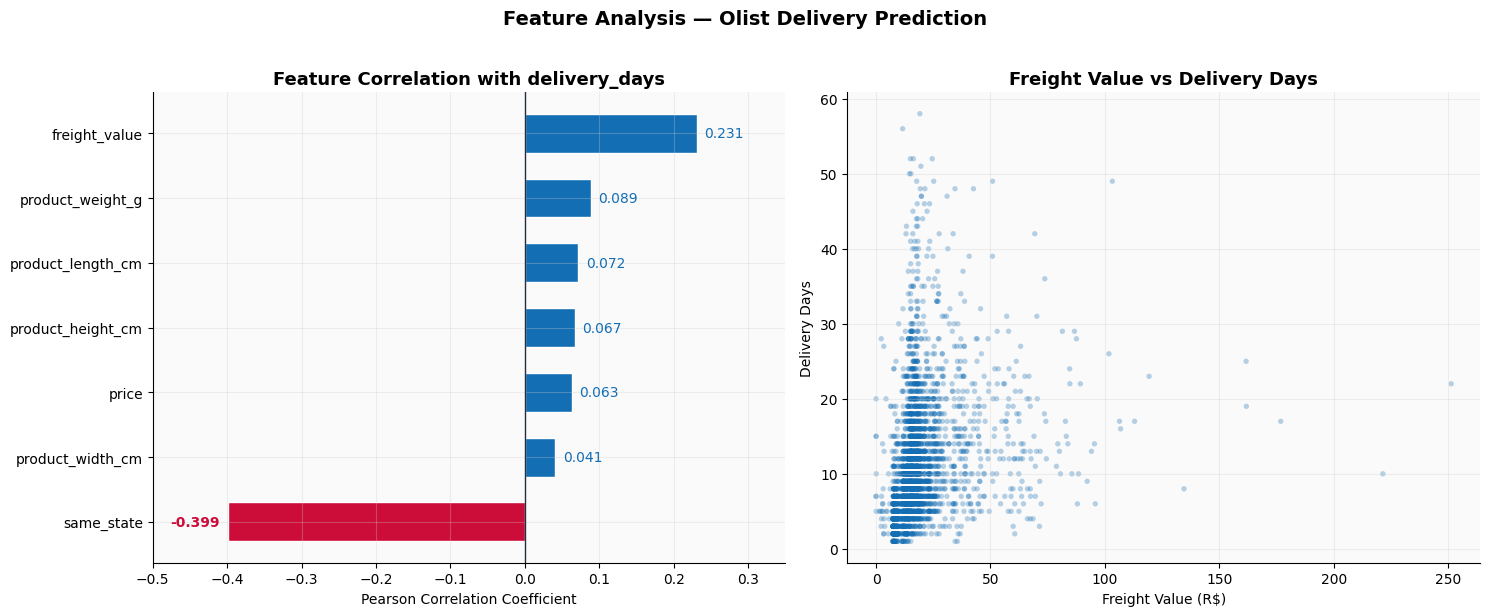

In [43]:
# ── CELL 10b: Feature correlation visualization ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Plot 1: Correlation bar chart (fixed label positions) ─────────────────────
correlations = df_model[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).sort_values()
bar_colors = [COLORS['danger'] if v < 0 else COLORS['secondary'] for v in correlations.values]

bars = axes[0].barh(correlations.index, correlations.values,
                    color=bar_colors, edgecolor='white', height=0.6)
axes[0].axvline(0, color=COLORS['primary'], linewidth=1)
axes[0].set_title('Feature Correlation with delivery_days',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pearson Correlation Coefficient')

# Fixed label positions — always outside the bar
for bar, val in zip(bars, correlations.values):
    if val < 0:
        axes[0].text(val - 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', ha='right',
                     fontsize=10, fontweight='bold', color=COLORS['danger'])
    else:
        axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', ha='left',
                     fontsize=10, color=COLORS['secondary'])

# Give more room on left side for the negative bar label
axes[0].set_xlim(-0.50, 0.35)

# ── Plot 2: freight_value vs delivery_days scatter ────────────────────────────
sample = df_model.sample(3000, random_state=42)
axes[1].scatter(sample['freight_value'], sample[TARGET_COL],
                alpha=0.3, color=COLORS['secondary'], s=15, edgecolors='none')
axes[1].set_title('Freight Value vs Delivery Days',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Freight Value (R$)')
axes[1].set_ylabel('Delivery Days')

plt.suptitle('Feature Analysis — Olist Delivery Prediction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
**📋 Observations — Feature Correlation & Scatter Plot:**

**Correlation Bar Chart:**
- `same_state` is the **strongest predictor by far** (−0.399) — being in the same state as the seller reduces delivery time significantly. This single binary feature carries more predictive signal than all physical product dimensions combined
- `freight_value` (0.231) is the strongest positive predictor — higher shipping cost is a reliable proxy for delivery distance and package size
- Product dimensions (`weight` 0.089, `length` 0.072, `height` 0.067, `width` 0.041) all have weak positive correlations — larger items take slightly longer but the effect is small
- `price` (0.063) has near-zero correlation — item value does not predict delivery speed
- Overall all correlations are relatively low — this confirms delivery time is a complex problem requiring non-linear models

**Freight Value vs Delivery Days Scatter:**
- The scatter shows a **wide spread at low freight values** (R$0–50) — most orders cluster here with delivery times ranging from 1 to 30 days
- At higher freight values (R$100+) the spread narrows and points thin out — fewer but generally slower deliveries
- No clean linear relationship is visible — the cloud shape confirms why linear models achieve only R² of 0.174
- This visual motivates our use of Random Forest and Neural Network which can capture these complex non-linear patterns

---
## 🤖 Model 4 — SVR (Support Vector Regressor)
## 🤖 Model 5 — Decision Tree Regressor

SVR finds a tube of acceptable error around predictions and ignores points that fall within it — only the points outside the tube (support vectors) influence the model. It is highly sensitive to feature scale so it **must** use `StandardScaler` inside a Pipeline.

Decision Tree splits the data using yes/no questions on feature thresholds — it can capture non-linear patterns but risks overfitting without depth control. We set `max_depth=6` to prevent this.

In [44]:
# ── CELL 11: Models 4, 5 — SVR and Decision Tree ─────────────────────────────
print('Training SVR and Decision Tree...\n')

# ── Model 4: SVR — MUST use StandardScaler in Pipeline ───────────────────────
# ⚠️  SVR is distance-based — features must be on the same scale
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVR(kernel='rbf', C=1.0, epsilon=0.1))
])
svr_pipeline, y_pred_svr = evaluate_model(
    'SVR', svr_pipeline, X_train, X_test, y_train, y_test
)

# ── Model 5: Decision Tree ────────────────────────────────────────────────────
# max_depth=6 prevents overfitting — unconstrained trees memorize training data
dt_pipeline = Pipeline([
    ('model', DecisionTreeRegressor(max_depth=6, random_state=42))
])
dt_pipeline, y_pred_dt = evaluate_model(
    'Decision Tree', dt_pipeline, X_train, X_test, y_train, y_test
)

# ── Partial results so far ────────────────────────────────────────────────────
print(f'\n=== Results So Far ===')
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Training SVR and Decision Tree...

  ✅ SVR                            RMSE: 7.522  MAE: 4.947  R²: 0.160  (155.80s)
  ✅ Decision Tree                  RMSE: 7.310  MAE: 5.127  R²: 0.207  (0.15s)

=== Results So Far ===
            Model  RMSE   MAE    R²  Train Time
Linear Regression 7.460 5.307 0.174       0.032
 Lasso Regression 7.464 5.314 0.173       0.020
 Ridge Regression 7.460 5.307 0.174       0.018
              SVR 7.522 4.947 0.160     155.805
    Decision Tree 7.310 5.127 0.207       0.152


---
**📋 Observations — SVR and Decision Tree:**

- **Decision Tree achieved the best RMSE so far (7.310)** — beating all three linear models. This confirms delivery time has non-linear patterns that tree-based splits can capture better than straight lines
- **R² improved to 0.207** — Decision Tree explains 20.7% of variance vs 17.4% for linear models. A meaningful improvement
- **SVR underperformed at default settings** (RMSE 7.522) — SVR is highly sensitive to the `C` and `epsilon` hyperparameters. Default values are rarely optimal. This model is a strong candidate for GridSearchCV tuning
- **SVR MAE of 4.947 is the best so far** — SVR makes smaller typical errors but occasionally larger ones, which RMSE penalizes more heavily
- **SVR training time was 155 seconds** — computationally expensive on 87,000 rows. In production, this cost must be justified by accuracy gains
- Decision Tree's `max_depth=6` constraint is working — without it the tree would memorize training data and fail on unseen orders

---
## 🤖 Model 6 — Random Forest Regressor

Random Forest builds hundreds of Decision Trees, each trained on a random subset of data and features. The final prediction is the average across all trees. This ensemble approach reduces overfitting dramatically compared to a single tree and typically delivers the best performance among traditional ML models.

A key advantage of Random Forest is **feature importance** — it tells us exactly how much each feature contributed to the predictions across all trees.

Training Random Forest...

  ✅ Random Forest                  RMSE: 7.110  MAE: 4.962  R²: 0.250  (2.46s)


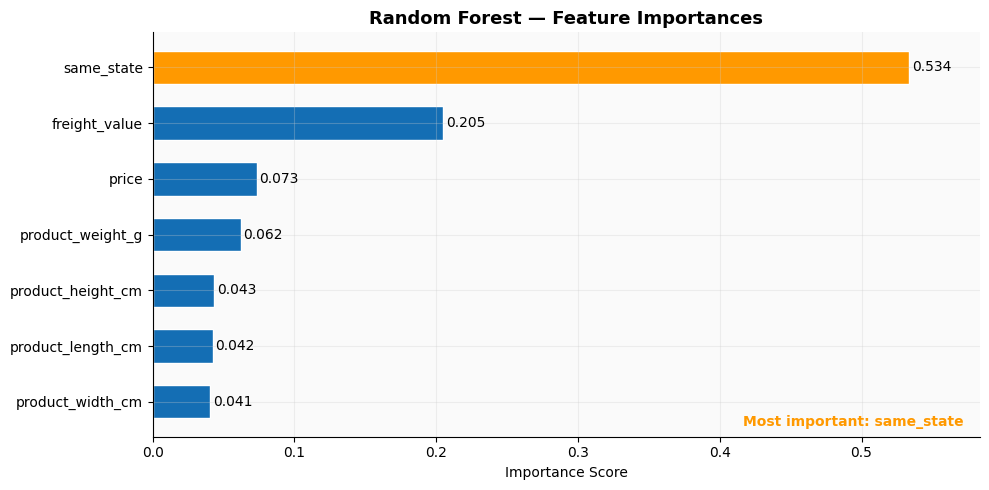


=== Results So Far ===
            Model  RMSE   MAE    R²  Train Time
Linear Regression 7.460 5.307 0.174       0.032
 Lasso Regression 7.464 5.314 0.173       0.020
 Ridge Regression 7.460 5.307 0.174       0.018
              SVR 7.522 4.947 0.160     155.805
    Decision Tree 7.310 5.127 0.207       0.152
    Random Forest 7.110 4.962 0.250       2.461


In [45]:
# ── CELL 12: Model 6 — Random Forest ─────────────────────────────────────────
print('Training Random Forest...\n')

# ── Model 6: Random Forest ────────────────────────────────────────────────────
rf_pipeline = Pipeline([
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1        # use all CPU cores — speeds up training
    ))
])
rf_pipeline, y_pred_rf = evaluate_model(
    'Random Forest', rf_pipeline, X_train, X_test, y_train, y_test
)

# ── Feature Importance Plot ───────────────────────────────────────────────────
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [COLORS['accent'] if f == feat_imp.iloc[-1]['Feature']
              else COLORS['secondary'] for f in feat_imp['Feature']]
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
               color=bar_colors, edgecolor='white', height=0.6)

# Add value labels
for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left', fontsize=10)

ax.set_title('Random Forest — Feature Importances',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, feat_imp['Importance'].max() + 0.05)

# Highlight most important feature
ax.text(0.98, 0.02, f'Most important: {feat_imp.iloc[-1]["Feature"]}',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=10, color=COLORS['accent'], fontweight='bold')

plt.tight_layout()
plt.show()

# ── Updated results table ─────────────────────────────────────────────────────
print(f'\n=== Results So Far ===')
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

---
**📋 Observations — Random Forest:**

- **Random Forest achieves the best RMSE so far (7.110)** — a clear improvement over the Decision Tree (7.310) and all linear models (7.460). Averaging 100 trees reduces variance and prevents overfitting
- **R² of 0.250** — the model now explains 25% of delivery time variance, the highest so far. Each model step is meaningfully improving on the last
- **Training time of only 2.46 seconds** — dramatically faster than SVR (155s) with significantly better accuracy. An excellent efficiency-to-performance ratio

**Feature Importances:**
- **`same_state` accounts for 53.4% of predictive power** — this single engineered binary feature dominates the entire model. Geography is overwhelmingly the most important factor in Brazilian delivery times
- **`freight_value` contributes 20.5%** — shipping cost is a reliable proxy for delivery distance and package complexity
- **`price` (7.3%) and `product_weight_g` (6.2%)** contribute modestly — heavier and more expensive items tend to take slightly longer
- **Product dimensions** (`height`, `length`, `width`) each contribute around 4% — individually weak but collectively they add meaningful signal
- Random Forest's feature importances **confirm and quantify** what the correlation analysis suggested — geography first, logistics cost second, product characteristics third

---
## 🤖 Model 7 — Neural Network (Keras)

A Neural Network learns complex non-linear relationships through layers of interconnected neurons. Each layer transforms the input, progressively extracting higher-level patterns. For regression, the output layer must be a single neuron with **no activation function** — this allows it to predict any continuous value.

Key rules for this Neural Network:
- `StandardScaler` inside a Pipeline — mandatory, NNs are extremely sensitive to feature scale
- Output layer: `Dense(1)` with no activation — regression output
- `EarlyStopping` with `restore_best_weights=True` — stops training when validation loss stops improving

Training Neural Network...



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 83.9335 - mae: 6.4373 - val_loss: 59.7804 - val_mae: 5.4715
Epoch 2/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 58.2223 - mae: 5.4060 - val_loss: 56.9721 - val_mae: 5.3531
Epoch 3/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - loss: 57.1301 - mae: 5.3576 - val_loss: 56.4383 - val_mae: 5.3313
Epoch 4/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - loss: 56.8475 - mae: 5.3407 - val_loss: 56.1870 - val_mae: 5.3136
Epoch 5/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step - loss: 56.6862 - mae: 5.3298 - val_loss: 56.0388 - val_mae: 5.3016
Epoch 6/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 56.5634 - mae: 5.3209 - val_loss: 55.9328 - val_mae: 5.2909
Epoch 7/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step - loss: 56.4607 - mae: 5.3135 - val_loss: 55.8438 - val_mae: 5.2816
Epoch 8/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 56.3707 - mae: 5.3070 - val_loss: 55.7654 - val_mae: 5.2727
Epoch 9/100
309/30

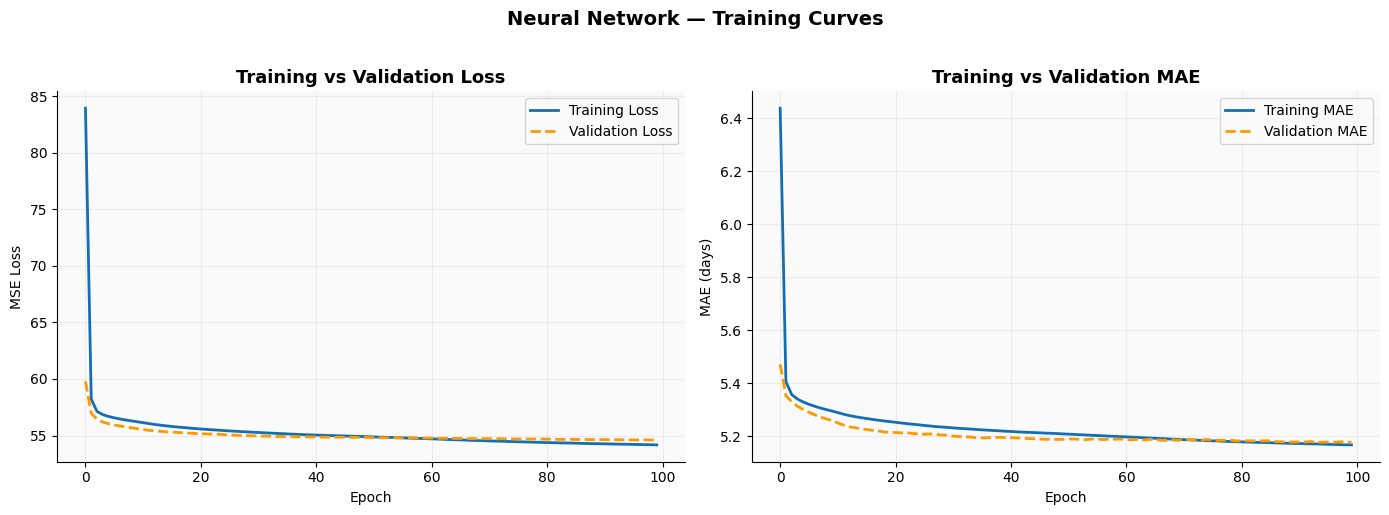


=== Results So Far — All 7 Models ===
            Model  RMSE   MAE    R²  Train Time
Linear Regression 7.460 5.307 0.174       0.032
 Lasso Regression 7.464 5.314 0.173       0.020
 Ridge Regression 7.460 5.307 0.174       0.018
              SVR 7.522 4.947 0.160     155.805
    Decision Tree 7.310 5.127 0.207       0.152
    Random Forest 7.110 4.962 0.250       2.461
   Neural Network 7.275 5.079 0.215      21.338


In [46]:
# ── CELL 13: Model 7 — Neural Network ────────────────────────────────────────
print('Training Neural Network...\n')

# ── Scale data manually for Keras (Pipeline doesn't work directly with Keras) ─
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train)  # fit on train only
X_test_nn  = scaler_nn.transform(X_test)       # transform test using train stats

# ── Build the Neural Network ──────────────────────────────────────────────────
tf.random.set_seed(42)

nn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)   # ⚠️ No activation — regression output must be unbounded
])

nn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

nn_model.summary()

# ── Early stopping ────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True  # ⚠️ Always use this — reverts to best epoch
)

# ── Train ─────────────────────────────────────────────────────────────────────
start = time.time()
history = nn_model.fit(
    X_train_nn, y_train,
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
train_time = time.time() - start

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred_nn = nn_model.predict(X_test_nn, verbose=0).flatten()
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mae_nn  = mean_absolute_error(y_test, y_pred_nn)
r2_nn   = r2_score(y_test, y_pred_nn)

results.append({
    'Model'     : 'Neural Network',
    'RMSE'      : round(rmse_nn, 3),
    'MAE'       : round(mae_nn, 3),
    'R²'        : round(r2_nn, 3),
    'Train Time': round(train_time, 3)
})

print(f'\n  ✅ Neural Network                 RMSE: {rmse_nn:.3f}  MAE: {mae_nn:.3f}  R²: {r2_nn:.3f}  ({train_time:.2f}s)')

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'],
             color=COLORS['secondary'], linewidth=2, label='Training Loss')
axes[0].plot(history.history['val_loss'],
             color=COLORS['accent'], linewidth=2,
             linestyle='--', label='Validation Loss')
axes[0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# MAE curve
axes[1].plot(history.history['mae'],
             color=COLORS['secondary'], linewidth=2, label='Training MAE')
axes[1].plot(history.history['val_mae'],
             color=COLORS['accent'], linewidth=2,
             linestyle='--', label='Validation MAE')
axes[1].set_title('Training vs Validation MAE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (days)')
axes[1].legend()

plt.suptitle('Neural Network — Training Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Updated results table ─────────────────────────────────────────────────────
print(f'\n=== Results So Far — All 7 Models ===')
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

---
**📋 Observations — Neural Network:**

- **Neural Network achieved RMSE 7.275** — better than all linear models and SVR, but did not beat Random Forest (7.110). This is a common finding — Neural Networks need large feature-rich datasets to outshine ensemble methods
- **R² of 0.215** — explains 21.5% of variance, better than linear models but behind Random Forest's 25%
- **Training ran all 100 epochs** — EarlyStopping did not trigger, meaning the model kept making small improvements throughout. The slow steady decline in loss is visible in the training curves
- **Training and validation curves track very closely** — no overfitting detected. The model generalizes well to unseen orders
- **Architecture: 64 → 32 → 16 → 1** — only 3,137 trainable parameters, a lightweight network appropriate for 7 input features
- **Output layer `Dense(1)` with no activation** — correct for regression. Any activation function would constrain the output range and prevent the model from predicting arbitrary delivery day values
- **Training time: 21 seconds** — significantly faster than SVR (155s) with better accuracy

**Running Leaderboard after all 7 models:**

| Rank | Model | RMSE | R² |
|---|---|---|---|
| 🥇 1 | Random Forest | 7.110 | 0.250 |
| 🥈 2 | Neural Network | 7.275 | 0.215 |
| 🥉 3 | Decision Tree | 7.310 | 0.207 |
| 4 | Linear Regression | 7.460 | 0.174 |
| 5 | Ridge Regression | 7.460 | 0.174 |
| 6 | Lasso Regression | 7.464 | 0.173 |
| 7 | SVR | 7.522 | 0.160 |

Random Forest leads — and it's also the model we will tune next with GridSearchCV.